<a href="https://colab.research.google.com/github/hcproc/VScode-/blob/main/forest_fire_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- STARTING ADVANCED FIRE DETECTION PIPELINE ---
Unzipping dataset...
Done.
Found dataset in: ./Forest Fire Dataset
Checking test folder structure...
Moved 380 test images.
Found 1216 images belonging to 2 classes.
Found 304 images belonging to 2 classes.
Found 380 images belonging to 2 classes.
Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62720)          │       250,880 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,028,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,537,281 (40.20 MB)

 Trainable params: 8,153,857 (31.10 MB)

 Non-trainable params: 2,383,424 (9.09 MB)


--- TRAINING STARTED ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 52s 902ms/step - accuracy: 0.8862 - loss: 0.2738 - val_accuracy: 0.9507 - val_loss: 0.2473
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 472ms/step - accuracy: 0.9772 - loss: 0.0920 - val_accuracy: 0.9737 - val_loss: 0.0851
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 495ms/step - accuracy: 0.9763 - loss: 0.0897 - val_accuracy: 0.9803 - val_loss: 0.0763
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 476ms/step - accuracy: 0.9837 - loss: 0.0431 - val_accuracy: 0.9704 - val_loss: 0.0691
Epoch 5/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 498ms/step - accuracy: 0.9795 - loss: 0.0826 - val_accuracy: 0.9836 - val_loss: 0.0635
Epoch 6/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 467ms/step - accuracy: 0.9848 - loss: 0.0977 - val_accuracy: 0.9836 - val_loss: 0.1046
Epoch 7/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 493ms/step - accuracy: 0.9811 - loss: 0.0661 - val_accuracy: 0.9868 - val_loss: 0.0886
Epoch 8/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 469ms/step - accuracy: 0.9901 - loss: 0.0439 - val_accu

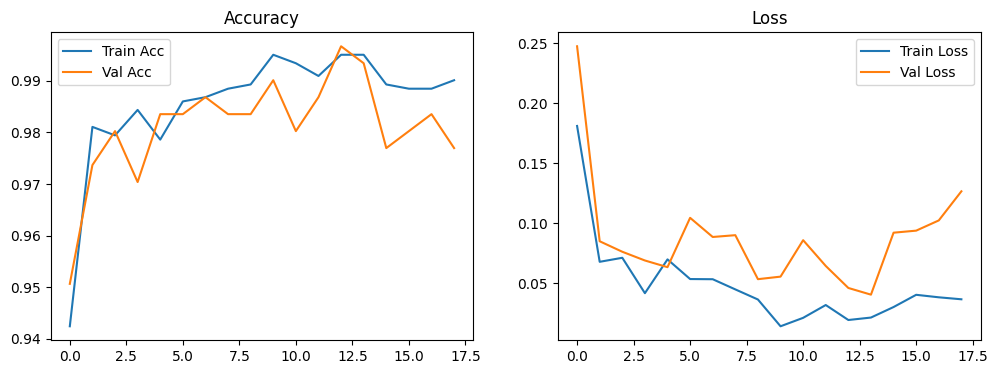


--- EVALUATION ON TEST SET ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step


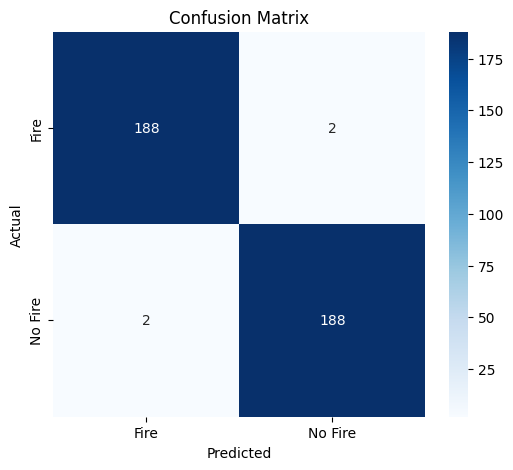

              precision    recall  f1-score   support

        Fire       0.99      0.99      0.99       190
     No Fire       0.99      0.99      0.99       190

    accuracy                           0.99       380
   macro avg       0.99      0.99      0.99       380
weighted avg       0.99      0.99      0.99       380



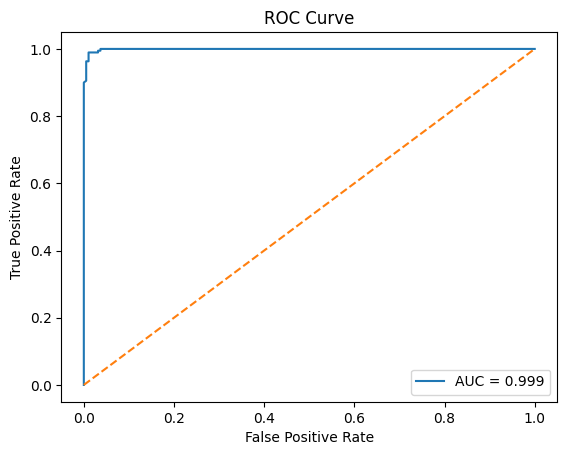

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import zipfile, os, shutil
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils import class_weight

print("\n--- STARTING ADVANCED FIRE DETECTION PIPELINE ---")

# -------------------------------------------------
# STEP 1: UNZIP DATASET
# -------------------------------------------------
if os.path.exists('dataset.zip'):
    print("Unzipping dataset...")
    with zipfile.ZipFile("dataset.zip", 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Done.")
else:
    print("dataset.zip not found. Assuming extracted.")

# -------------------------------------------------
# STEP 2: FIND DATA FOLDERS
# -------------------------------------------------
train_dir = "./Training"
test_dir = "./Testing"

if not (os.path.exists(train_dir) and os.path.exists(test_dir)):
    for root, dirs, files in os.walk("."):
        if "Training" in dirs and "Testing" in dirs:
            train_dir = os.path.join(root, "Training")
            test_dir = os.path.join(root, "Testing")
            print(f"Found dataset in: {root}")
            break

# -------------------------------------------------
# STEP 3: FIX TEST FOLDER STRUCTURE
# -------------------------------------------------
print("Checking test folder structure...")

fire_sub = os.path.join(test_dir, "fire")
nofire_sub = os.path.join(test_dir, "nofire")
os.makedirs(fire_sub, exist_ok=True)
os.makedirs(nofire_sub, exist_ok=True)

moved = 0
for f in os.listdir(test_dir):
    src = os.path.join(test_dir, f)
    if not os.path.isfile(src):
        continue
    if f.lower().startswith("fire"):
        shutil.move(src, os.path.join(fire_sub, f))
        moved += 1
    elif f.lower().startswith("nofire"):
        shutil.move(src, os.path.join(nofire_sub, f))
        moved += 1

print(f"Moved {moved} test images.")

# -------------------------------------------------
# STEP 4: DATA GENERATORS
# -------------------------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

val_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

test_set = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

# -------------------------------------------------
# STEP 5: CLASS WEIGHT (IMBALANCE HANDLING)
# -------------------------------------------------
weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_set.classes),
    y=train_set.classes
)
class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)

# -------------------------------------------------
# STEP 6: TRANSFER LEARNING MODEL (MOBILENETV2)
# -------------------------------------------------
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # freeze pretrained layers

model = Sequential([
    base_model,
    Flatten(),
    BatchNormalization(),
    Dense(128, activation="relu"),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# -------------------------------------------------
# STEP 7: TRAINING WITH EARLY STOPPING
# -------------------------------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

print("\n--- TRAINING STARTED ---")

history = model.fit(
    train_set,
    epochs=25,
    validation_data=val_set,
    class_weight=class_weights,
    callbacks=[early_stop]
)

model.save("forest_fire_mobilenet.keras")
print("Model saved as forest_fire_mobilenet.keras")

# -------------------------------------------------
# STEP 8: TRAINING GRAPHS
# -------------------------------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()

# -------------------------------------------------
# STEP 9: TEST EVALUATION
# -------------------------------------------------
print("\n--- EVALUATION ON TEST SET ---")

pred = model.predict(test_set)
y_pred = (pred > 0.5).astype(int)
y_true = test_set.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fire","No Fire"],
            yticklabels=["Fire","No Fire"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=["Fire","No Fire"]))

# -------------------------------------------------
# STEP 10: ROC CURVE
# -------------------------------------------------
fpr, tpr, _ = roc_curve(y_true, pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

--- STARTING AUTOMATED PIPELINE ---
Found dataset.zip! Unzipping...
Unzipped successfully!
Standard folders not found. Searching subdirectories...
Found data in: ./Forest Fire Dataset
Checking and organizing ./Forest Fire Dataset/Testing...
Fixed! Moved 380 loose images.

--- LOADING DATA ---
Found 1520 images belonging to 2 classes.
Found 380 images belonging to 2 classes.

--- STARTING TRAINING ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 28s 456ms/step - accuracy: 0.8023 - loss: 0.5408 - val_accuracy: 0.8974 - val_loss: 0.2429
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 409ms/step - accuracy: 0.9434 - loss: 0.1409 - val_accuracy: 0.8974 - val_loss: 0.2661
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 407ms/step - accuracy: 0.9636 - loss: 0.1175 - val_accuracy: 0.9132 - val_loss: 0.2632
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 408ms/step - accuracy: 0.9533 - loss: 0.1474 - val_accuracy: 0.9632 - val_loss: 0.1122
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 19s 400ms/step - accuracy: 0.9605 - loss: 0.1206 - val_accuracy: 0.9342 - val_loss: 0.1997
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 19s 398ms/step - accuracy: 0.9656 - loss: 0.0991 - val_accuracy: 0.9316 - val_loss: 0.1723
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 416ms/step - accuracy: 0.9620 - loss: 0.1088 - val_accuracy: 0.9632 - val_loss: 0.1067
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 19s 392ms/step - accuracy: 0.9783 - loss: 0.0846 - val_accu

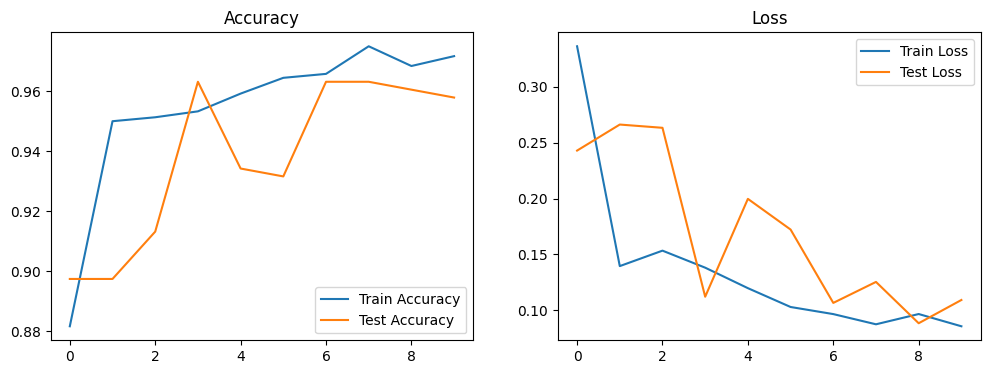


--- GENERATING EVALUATION METRICS ---
Found 380 images belonging to 2 classes.
Predicting...
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step


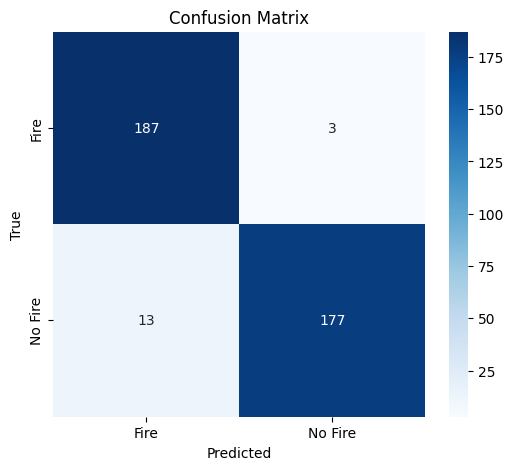

              precision    recall  f1-score   support

        Fire       0.94      0.98      0.96       190
     No Fire       0.98      0.93      0.96       190

    accuracy                           0.96       380
   macro avg       0.96      0.96      0.96       380
weighted avg       0.96      0.96      0.96       380



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import zipfile
import os
import shutil
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("--- STARTING AUTOMATED PIPELINE ---")

# --- STEP 1: Unzip the Dataset ---
if os.path.exists('dataset.zip'):
    print("Found dataset.zip! Unzipping...")
    try:
        with zipfile.ZipFile("dataset.zip", 'r') as zip_ref:
            zip_ref.extractall(".")
        print("Unzipped successfully!")
    except zipfile.BadZipFile:
        print("ERROR: 'dataset.zip' is corrupted. Please upload a valid .zip file!")
else:
    print("WARNING: 'dataset.zip' not found. Assuming files are already extracted...")

# --- STEP 2: Find the Folders Automatically ---
base_dir = "."
train_dir = os.path.join(base_dir, 'Training')
test_dir = os.path.join(base_dir, 'Testing')

if not (os.path.exists(train_dir) and os.path.exists(test_dir)):
    print("Standard folders not found. Searching subdirectories...")
    for root, dirs, files in os.walk("."):
        if "Training" in dirs and "Testing" in dirs:
            train_dir = os.path.join(root, "Training")
            test_dir = os.path.join(root, "Testing")
            print(f"Found data in: {root}")
            break

# --- STEP 3: THE FIX - Sort Test Images into Subfolders ---
print(f"Checking and organizing {test_dir}...")
fire_subdir = os.path.join(test_dir, 'fire')
nofire_subdir = os.path.join(test_dir, 'nofire')
os.makedirs(fire_subdir, exist_ok=True)
os.makedirs(nofire_subdir, exist_ok=True)

moved_count = 0
if os.path.exists(test_dir):
    for filename in os.listdir(test_dir):
        src_path = os.path.join(test_dir, filename)
        if not os.path.isfile(src_path): continue

        if filename.lower().startswith('fire'):
            shutil.move(src_path, os.path.join(fire_subdir, filename))
            moved_count += 1
        elif filename.lower().startswith('nofire'):
            shutil.move(src_path, os.path.join(nofire_subdir, filename))
            moved_count += 1

if moved_count > 0:
    print(f"Fixed! Moved {moved_count} loose images.")
else:
    print("Folders look good.")

# --- STEP 4: Load Images ---
print("\n--- LOADING DATA ---")
train_datagen = ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)

train_set = train_datagen.flow_from_directory(
    train_dir, target_size=(224, 224), batch_size=32, class_mode='binary')

test_set = test_datagen.flow_from_directory(
    test_dir, target_size=(224, 224), batch_size=32, class_mode='binary')

# --- STEP 5: Build the Model ---
model = Sequential([
    Input(shape=(224, 224, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- STEP 6: Train ---
print("\n--- STARTING TRAINING ---")
if train_set.samples > 0:
    history = model.fit(train_set, epochs=10, validation_data=test_set if test_set.samples > 0 else None)
    model.save('forest_fire_model.keras')
    print("Model saved as 'forest_fire_model.keras'")

    # --- STEP 7: Visualization (Graphs) ---
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    if test_set.samples > 0:
        plt.plot(history.history['val_accuracy'], label='Test Accuracy')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    if test_set.samples > 0:
        plt.plot(history.history['val_loss'], label='Test Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()

   # --- STEP 8: Evaluation (THE FIX) ---
print("\n--- GENERATING EVALUATION METRICS ---")

if test_set.samples > 0:
    # 1. RE-CREATE the test generator with shuffle=False
    # This is the secret sauce. It forces images to load in alphanumeric order
    # so they match the labels perfectly.
    eval_set = test_datagen.flow_from_directory(
        test_dir,
        target_size=(224, 224),
        batch_size=32,
        class_mode='binary',
        shuffle=False  # <--- CRITICAL CHANGE HERE
    )

    # 2. Get Predictions
    print("Predicting...")
    predictions = model.predict(eval_set)

    # 3. Convert to Binary
    y_pred = np.where(predictions > 0.5, 1, 0)

    # 4. Get True Labels
    y_true = eval_set.classes

    # 5. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fire', 'No Fire'],
                yticklabels=['Fire', 'No Fire'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    # 6. Classification Report
    print(classification_report(y_true, y_pred, target_names=['Fire', 'No Fire']))
else:
    print("Skipping evaluation: No test data found.")



In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Reset the test generator
# (Critical: ensures images aren't shuffled!)
test_set.reset()

# 2. Get the model's predictions
# This gives probabilities (e.g., 0.92, 0.04)
predictions = model.predict(test_set)

# 3. Convert probabilities to Binary (0 or 1)
# If probability > 50%, call it Class 1
y_pred = np.where(predictions > 0.5, 1, 0)

# 4. Get the actual answers (True Labels)
y_true = test_set.classes



# Generate the Matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize it
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fire', 'No Fire'],
            yticklabels=['Fire', 'No Fire'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Print the detailed report
print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=['Fire', 'No Fire']))

NameError: name 'test_set' is not defined

### Overall Goal

The code sets up a complete workflow for training a deep learning model to classify images as either 'fire' or 'no fire'. It handles data loading, preprocessing, model definition, training, and evaluation visualization.

### STEP 1: Unzip the Dataset

This section first checks if a `dataset.zip` file exists in the current directory. If found, it attempts to unzip its contents. It includes error handling for cases where the file might be corrupted or not found.

### STEP 2: Verify Folder Structure

After unzipping, the code looks for standard 'Training' and 'Testing' directories which are expected to contain the image data. If they are not immediately found at the top level, it searches for them within subfolders to correctly set the `train_dir` and `test_dir` paths.

### STEP 3: Image Preprocessing

This is a crucial step for preparing image data for a CNN:

*   **`ImageDataGenerator`**: This TensorFlow utility helps in efficiently loading images from directories and applying real-time data augmentation.
*   **Data Augmentation (for `train_datagen`)**:
    *   `rescale=1./255`: Normalizes pixel values from the 0-255 range to 0-1, which is standard for neural networks.
    *   `shear_range=0.2`: Randomly applies shearing transformations.
    *   `zoom_range=0.2`: Randomly zooms into images.
    *   `horizontal_flip=True`: Randomly flips images horizontally. These augmentations help the model generalize better by seeing varied versions of the training data.
*   **Test Data Preprocessing (for `test_datagen`)**:
    *   Only `rescale=1./255` is applied. Augmentation is typically not used on test/validation data as we want to evaluate the model on realistic, unaltered images.
*   **`flow_from_directory`**: Loads images from the specified directories.
    *   `target_size=(224, 224)`: Resizes all images to 224x224 pixels, a common input size for CNNs.
    *   `batch_size=32`: Loads images in batches of 32 during training.
    *   `class_mode='binary'`: Indicates that the problem is a binary classification task (e.g., 'fire' vs. 'no fire').

### STEP 4: Build the CNN Model

This section defines the architecture of the Convolutional Neural Network using `tf.keras.models.Sequential`:

*   **`Conv2D` (Convolutional Layers)**: These are the 'eyes' of the CNN, detecting features like edges, textures, and patterns in images. `32`, `64`, `128` refer to the number of filters, and `(3, 3)` is the kernel size. `activation='relu'` is a common activation function.
*   **`MaxPooling2D`**: Reduces the spatial dimensions of the feature maps, helping to make the model more robust to small shifts and distortions in the input and reducing computational cost.
*   **`Flatten()`**: Converts the 2D feature maps into a 1D vector, preparing the data for the fully connected (Dense) layers.
*   **`Dense` (Fully Connected Layers)**: These are the 'brain' of the CNN, interpreting the features extracted by the convolutional layers.
    *   `Dense(128, activation='relu')`: A hidden layer with 128 neurons.
    *   `Dropout(0.3)`: Randomly sets 30% of input units to 0 at each update during training. This technique helps prevent overfitting by forcing the network to learn more robust features.
    *   `Dense(1, activation='sigmoid')`: The output layer. For binary classification, a single neuron with a sigmoid activation function outputs a probability between 0 and 1 (e.g., probability of being 'fire').

### STEP 5: Compile & Train

This step configures and executes the training process:

*   **`model.compile`**: Configures the learning process.
    *   `optimizer='adam'`: An efficient optimization algorithm used to adjust model weights during training.
    *   `loss='binary_crossentropy'`: The standard loss function for binary classification, which measures the difference between the predicted probabilities and the actual labels.
    *   `metrics=['accuracy']`: The metric used to evaluate the model's performance during training (proportion of correctly classified samples).
*   **`model.fit`**: Starts the training of the model.
    *   `train_set`: The training data generator.
    *   `epochs=10`: The number of times the model will iterate over the entire training dataset.
    *   `validation_data=test_set`: The data used to evaluate the model's performance after each epoch (this is omitted if `test_set` is empty, as indicated by the warning in the output).

### STEP 6: Save & Graph

Finally, the trained model is saved, and its performance is visualized:

*   **`model.save('forest_fire_model.keras')`**: Saves the trained model's architecture, weights, and training configuration so it can be reloaded and used later without retraining.
*   **Plotting with `matplotlib.pyplot`**: Visualizes the training history, showing:
    *   **Accuracy**: How well the model performed on the training data and (if available) the validation data over each epoch. A higher accuracy is better.
    *   **Loss**: How well the model performed on the training data and (if available) the validation data over each epoch. A lower loss is better.